# 07 — Object-Centric Zoom for Fine-Grained Part Segmentation

## Motivation

DINOv2 ViT-S/14 produces a 16 × 16 feature grid for a 224 × 224 image.

If the parent object occupies only a small portion of the full image,
fine-grained parts such as eyes, feet, ears, handles, or small wheels may
occupy less than one DINO patch.

This notebook investigates object-centric zoom.

Instead of feeding the complete image to DINOv2:

original image
    ↓
parent-object bounding box
    ↓
square crop with context
    ↓
resize directly from original resolution to 224 × 224
    ↓
DINOv2

This allocates more DINO patches to the selected object.

---

## Experiments

We repeat the three controlled models from Notebook 06:

### crop_mask_baseline

DINO + CLIP + parent-object mask

### crop_alignment_mask

DINO + CLIP + parent-object mask + part-query alignment

### crop_alignment_relative_uv

DINO + CLIP + parent-object mask + part-query alignment + relative U/V

The architecture remains identical.

Only the image view changes from full-image to object-centric.

---

## Main Questions

Does object-centric zoom:

- increase the number of DINO patches representing small parts?
- improve segmentation performance?
- help unseen parent-object categories?
- complement part-query alignment?
- especially help small parts?

For fair final evaluation, crop predictions are projected back to the
full-image coordinate system before IoU is calculated.

In [1]:
from pathlib import Path
import sys
import json
import random
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

import open_clip

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [3]:
from datasets import PascalPart116Dataset

print("PascalPart116Dataset imported successfully.")

PascalPart116Dataset imported successfully.


In [4]:
SEED = 42

IMAGE_SIZE = 224

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16

NUM_WORKERS = 4

EPOCHS = 20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VISUAL_DIM = 128
TEXT_COMMON_DIM = 128
TEXT_DECODER_DIM = 32

MASK_THRESHOLD = 0.5

ALIGNMENT_TEMPERATURE = 0.10
ALIGNMENT_LOSS_WEIGHT = 0.20

# 15% context on every side around the object.
CROP_CONTEXT_RATIO = 0.15

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = torch.cuda.is_available()

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "object_centric_zoom"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FULL_MODEL_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "part_query_alignment"
)

print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Crop context:", CROP_CONTEXT_RATIO)
print("Output:", OUTPUT_ROOT)

Device: cuda
AMP: True
Crop context: 0.15
Output: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/object_centric_zoom


In [5]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print("Seed:", SEED)

Seed: 42


In [6]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)

In [7]:
def get_resize_info(
    height,
    width,
    target_size=224,
):

    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(
        1,
        round(height * scale),
    )

    new_w = max(
        1,
        round(width * scale),
    )

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    top = pad_h // 2
    bottom = pad_h - top

    left = pad_w // 2
    right = pad_w - left

    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "scale": scale,
    }

In [8]:
def preprocess_full_image(
    image,
    target_size=224,
):

    image = (
        image.float()
        / 255.0
    )

    _, h, w = image.shape

    info = get_resize_info(
        h,
        w,
        target_size,
    )

    resized = TF.resize(
        image,
        [
            info["new_h"],
            info["new_w"],
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    display_image = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    normalized = (
        resized
        - IMAGENET_MEAN
    ) / IMAGENET_STD

    model_image = F.pad(
        normalized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    return (
        display_image,
        model_image,
        info,
    )

In [9]:
def preprocess_full_mask(
    mask,
    resize_info,
    preserve_positive=False,
):

    if mask.ndim == 2:
        mask = mask.unsqueeze(0)

    mask = mask.float()

    resized = TF.resize(
        mask,
        [
            resize_info["new_h"],
            resize_info["new_w"],
        ],
        interpolation=InterpolationMode.NEAREST,
    )

    if (
        preserve_positive
        and mask.sum() > 0
        and resized.sum() == 0
    ):

        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(
                resize_info["new_h"],
                resize_info["new_w"],
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return (
        padded > 0.5
    )

In [10]:
def create_relative_uv(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = object_mask.squeeze(0)
    else:
        mask = object_mask

    mask = mask.bool()

    h, w = mask.shape

    u = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    v = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    ys, xs = torch.where(mask)

    if len(xs) == 0:

        return (
            u.unsqueeze(0),
            v.unsqueeze(0),
        )

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    x_denom = max(
        int(x_max - x_min),
        1,
    )

    y_denom = max(
        int(y_max - y_min),
        1,
    )

    u_values = (
        xs.float()
        - x_min.float()
    ) / x_denom

    v_values = (
        ys.float()
        - y_min.float()
    ) / y_denom

    u[ys, xs] = u_values
    v[ys, xs] = v_values

    return (
        u.unsqueeze(0),
        v.unsqueeze(0),
    )

In [11]:
def get_square_object_crop(
    object_mask,
    context_ratio=0.15,
):

    if object_mask.ndim == 3:
        mask = object_mask.squeeze(0)
    else:
        mask = object_mask

    mask = mask.bool()

    h, w = mask.shape

    ys, xs = torch.where(mask)

    if len(xs) == 0:

        side = max(h, w)

        return {
            "x1": (w - side) // 2,
            "y1": (h - side) // 2,
            "side": side,
        }

    x_min = xs.min().item()
    x_max = xs.max().item() + 1

    y_min = ys.min().item()
    y_max = ys.max().item() + 1

    box_width = (
        x_max - x_min
    )

    box_height = (
        y_max - y_min
    )

    base_side = max(
        box_width,
        box_height,
    )

    side = math.ceil(
        base_side
        * (
            1
            + 2 * context_ratio
        )
    )

    side = max(
        side,
        1,
    )

    center_x = (
        x_min + x_max
    ) / 2

    center_y = (
        y_min + y_max
    ) / 2

    x1 = math.floor(
        center_x
        - side / 2
    )

    y1 = math.floor(
        center_y
        - side / 2
    )

    return {
        "x1": x1,
        "y1": y1,
        "side": side,
    }

In [12]:
def square_crop_with_padding(
    tensor,
    x1,
    y1,
    side,
    fill_value=0,
):

    original_ndim = tensor.ndim

    if tensor.ndim == 2:
        tensor = tensor.unsqueeze(0)

    channels, h, w = (
        tensor.shape
    )

    output = torch.full(
        (
            channels,
            side,
            side,
        ),
        fill_value=fill_value,
        dtype=tensor.dtype,
    )

    x2 = x1 + side
    y2 = y1 + side

    source_x1 = max(
        0,
        x1,
    )

    source_y1 = max(
        0,
        y1,
    )

    source_x2 = min(
        w,
        x2,
    )

    source_y2 = min(
        h,
        y2,
    )

    destination_x1 = (
        source_x1 - x1
    )

    destination_y1 = (
        source_y1 - y1
    )

    destination_x2 = (
        destination_x1
        + source_x2
        - source_x1
    )

    destination_y2 = (
        destination_y1
        + source_y2
        - source_y1
    )

    if (
        source_x1 < source_x2
        and source_y1 < source_y2
    ):

        output[
            :,
            destination_y1:destination_y2,
            destination_x1:destination_x2,
        ] = tensor[
            :,
            source_y1:source_y2,
            source_x1:source_x2,
        ]

    if original_ndim == 2:
        output = output.squeeze(0)

    return output

In [13]:
def prepare_crop_image(
    crop_image,
    target_size=224,
):

    crop_image = (
        crop_image.float()
        / 255.0
    )

    display_image = TF.resize(
        crop_image,
        [
            target_size,
            target_size,
        ],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    model_image = (
        display_image
        - IMAGENET_MEAN
    ) / IMAGENET_STD

    return (
        display_image,
        model_image,
    )

In [14]:
def prepare_crop_mask(
    crop_mask,
    target_size=224,
    preserve_positive=False,
):

    if crop_mask.ndim == 2:
        crop_mask = (
            crop_mask.unsqueeze(0)
        )

    crop_mask = (
        crop_mask.float()
    )

    resized = TF.resize(
        crop_mask,
        [
            target_size,
            target_size,
        ],
        interpolation=InterpolationMode.NEAREST,
    )

    if (
        preserve_positive
        and crop_mask.sum() > 0
        and resized.sum() == 0
    ):

        resized = F.interpolate(
            crop_mask.unsqueeze(0),
            size=(
                target_size,
                target_size,
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    return (
        resized > 0.5
    )

In [15]:
raw_dataset = PascalPart116Dataset(
    split="train_seen"
)

raw_sample = raw_dataset[0]

crop_info = get_square_object_crop(
    raw_sample["object_mask"],
    context_ratio=CROP_CONTEXT_RATIO,
)

crop_info

{'x1': -25, 'y1': -120, 'side': 531}

In [16]:
crop_rgb_raw = square_crop_with_padding(
    raw_sample["image"],
    crop_info["x1"],
    crop_info["y1"],
    crop_info["side"],
    fill_value=0,
)

crop_object_raw = square_crop_with_padding(
    raw_sample["object_mask"],
    crop_info["x1"],
    crop_info["y1"],
    crop_info["side"],
    fill_value=0,
)

crop_part_raw = square_crop_with_padding(
    raw_sample["part_mask"],
    crop_info["x1"],
    crop_info["y1"],
    crop_info["side"],
    fill_value=0,
)

print(
    "Original image:",
    raw_sample["image"].shape
)

print(
    "Raw crop:",
    crop_rgb_raw.shape
)

Original image: torch.Size([3, 375, 500])
Raw crop: torch.Size([3, 531, 531])


In [17]:
crop_display, crop_model_image = (
    prepare_crop_image(
        crop_rgb_raw,
        IMAGE_SIZE,
    )
)

crop_object = prepare_crop_mask(
    crop_object_raw,
    IMAGE_SIZE,
    preserve_positive=True,
)

crop_part = prepare_crop_mask(
    crop_part_raw,
    IMAGE_SIZE,
    preserve_positive=True,
)

if (
    crop_part.any()
    and not (
        crop_part
        & crop_object
    ).any()
):

    crop_object = (
        crop_object
        | crop_part
    )

crop_part = (
    crop_part
    & crop_object
)

print(crop_display.shape)
print(crop_object.shape)
print(crop_part.shape)

torch.Size([3, 224, 224])
torch.Size([1, 224, 224])
torch.Size([1, 224, 224])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


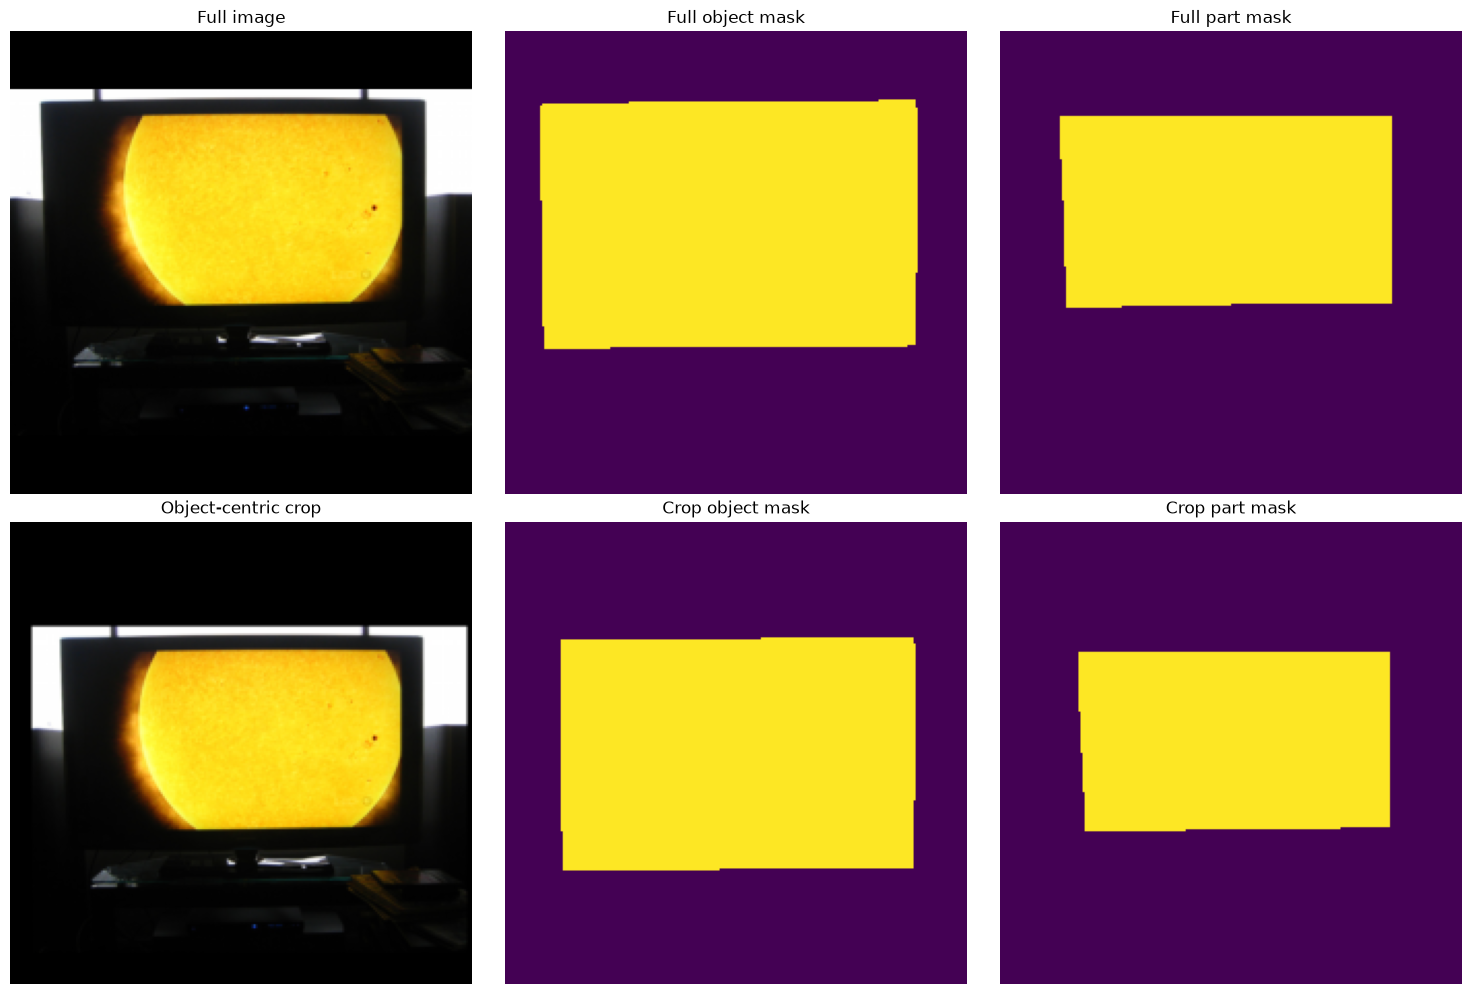

In [18]:
full_display, _, full_resize_info = (
    preprocess_full_image(
        raw_sample["image"],
        IMAGE_SIZE,
    )
)

full_object = preprocess_full_mask(
    raw_sample["object_mask"],
    full_resize_info,
    preserve_positive=True,
)

full_part = preprocess_full_mask(
    raw_sample["part_mask"],
    full_resize_info,
    preserve_positive=True,
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
)

axes[0, 0].imshow(
    full_display
    .permute(1, 2, 0)
)

axes[0, 0].set_title(
    "Full image"
)

axes[0, 1].imshow(
    full_object.squeeze()
)

axes[0, 1].set_title(
    "Full object mask"
)

axes[0, 2].imshow(
    full_part.squeeze()
)

axes[0, 2].set_title(
    "Full part mask"
)


axes[1, 0].imshow(
    crop_display
    .permute(1, 2, 0)
)

axes[1, 0].set_title(
    "Object-centric crop"
)

axes[1, 1].imshow(
    crop_object.squeeze()
)

axes[1, 1].set_title(
    "Crop object mask"
)

axes[1, 2].imshow(
    crop_part.squeeze()
)

axes[1, 2].set_title(
    "Crop part mask"
)


for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
def count_positive_dino_patches(
    mask,
    grid_size=16,
):

    if mask.ndim == 3:
        mask = mask.unsqueeze(0)

    coarse = F.adaptive_max_pool2d(
        mask.float(),
        output_size=(
            grid_size,
            grid_size,
        ),
    )

    count = (
        coarse > 0
    ).sum().item()

    return (
        int(count),
        coarse.squeeze(),
    )

In [20]:
full_patch_count, full_patch_map = (
    count_positive_dino_patches(
        full_part
    )
)

crop_patch_count, crop_patch_map = (
    count_positive_dino_patches(
        crop_part
    )
)

print(
    "Full-image target patches:",
    full_patch_count
)

print(
    "Object-crop target patches:",
    crop_patch_count
)

print(
    "Patch amplification:",
    crop_patch_count
    / max(
        full_patch_count,
        1,
    )
)

Full-image target patches: 96
Object-crop target patches: 84
Patch amplification: 0.875


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


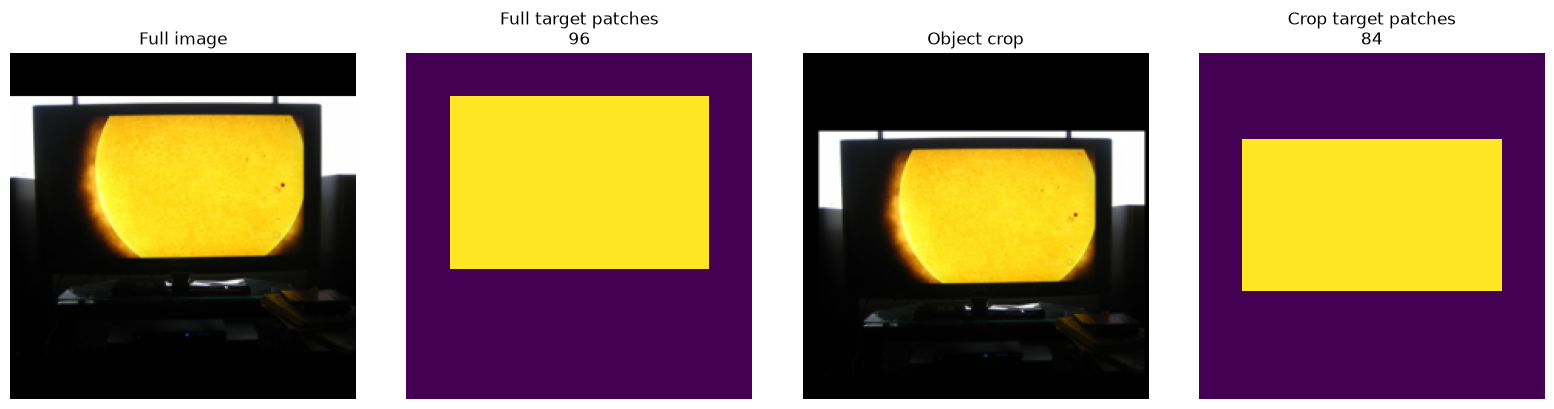

In [21]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

axes[0].imshow(
    full_display
    .permute(1, 2, 0)
)

axes[0].set_title(
    "Full image"
)

axes[1].imshow(
    full_patch_map
)

axes[1].set_title(
    f"Full target patches\n"
    f"{full_patch_count}"
)

axes[2].imshow(
    crop_display
    .permute(1, 2, 0)
)

axes[2].set_title(
    "Object crop"
)

axes[3].imshow(
    crop_patch_map
)

axes[3].set_title(
    f"Crop target patches\n"
    f"{crop_patch_count}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
class ObjectCentricDataset(Dataset):

    def __init__(
        self,
        split,
        image_size=224,
        context_ratio=0.15,
    ):

        self.base_dataset = (
            PascalPart116Dataset(
                split=split
            )
        )

        self.image_size = (
            image_size
        )

        self.context_ratio = (
            context_ratio
        )


    def __len__(self):

        return len(
            self.base_dataset
        )


    def __getitem__(
        self,
        index,
    ):

        sample = (
            self.base_dataset[index]
        )

        original_image = (
            sample["image"]
        )

        original_object = (
            sample["object_mask"]
        )

        original_part = (
            sample["part_mask"]
        )

        _, original_h, original_w = (
            original_image.shape
        )


        # =====================================
        # Full image representation
        # =====================================

        (
            full_display,
            full_image,
            full_resize_info,
        ) = preprocess_full_image(
            original_image,
            self.image_size,
        )


        full_object = preprocess_full_mask(
            original_object,
            full_resize_info,
            preserve_positive=True,
        )


        full_part = preprocess_full_mask(
            original_part,
            full_resize_info,
            preserve_positive=True,
        )


        if (
            full_part.any()
            and not (
                full_part
                & full_object
            ).any()
        ):

            full_object = (
                full_object
                | full_part
            )


        full_part = (
            full_part
            & full_object
        )


        full_u, full_v = (
            create_relative_uv(
                full_object
            )
        )


        # =====================================
        # Original-resolution object crop
        # =====================================

        crop_info = (
            get_square_object_crop(
                original_object,
                self.context_ratio,
            )
        )


        x1 = crop_info["x1"]
        y1 = crop_info["y1"]
        side = crop_info["side"]


        crop_rgb_raw = (
            square_crop_with_padding(
                original_image,
                x1,
                y1,
                side,
                fill_value=0,
            )
        )


        crop_object_raw = (
            square_crop_with_padding(
                original_object,
                x1,
                y1,
                side,
                fill_value=0,
            )
        )


        crop_part_raw = (
            square_crop_with_padding(
                original_part,
                x1,
                y1,
                side,
                fill_value=0,
            )
        )


        (
            crop_display,
            crop_image,
        ) = prepare_crop_image(
            crop_rgb_raw,
            self.image_size,
        )


        crop_object = (
            prepare_crop_mask(
                crop_object_raw,
                self.image_size,
                preserve_positive=True,
            )
        )


        crop_part = (
            prepare_crop_mask(
                crop_part_raw,
                self.image_size,
                preserve_positive=True,
            )
        )


        if (
            crop_part.any()
            and not (
                crop_part
                & crop_object
            ).any()
        ):

            crop_object = (
                crop_object
                | crop_part
            )


        crop_part = (
            crop_part
            & crop_object
        )


        crop_u, crop_v = (
            create_relative_uv(
                crop_object
            )
        )


        part_to_object_ratio = (
            full_part.sum().float()
            /
            full_object.sum()
            .float()
            .clamp_min(1)
        )


        return {

            "sample_id":
                sample["sample_id"],

            "image_id":
                sample["image_id"],

            "query":
                sample["query"],

            "object_name":
                sample["object_name"],

            "part_name":
                sample["part_name"],


            # =========================
            # Full view
            # =========================

            "full_display_image":
                full_display,

            "full_image":
                full_image,

            "full_object_mask":
                full_object.float(),

            "full_part_mask":
                full_part.float(),

            "full_relative_u":
                full_u,

            "full_relative_v":
                full_v,


            # =========================
            # Crop view
            # =========================

            "crop_display_image":
                crop_display,

            "crop_image":
                crop_image,

            "crop_object_mask":
                crop_object.float(),

            "crop_part_mask":
                crop_part.float(),

            "crop_relative_u":
                crop_u,

            "crop_relative_v":
                crop_v,


            # =========================
            # Mapping information
            # =========================

            "original_height":
                original_h,

            "original_width":
                original_w,

            "crop_x1":
                x1,

            "crop_y1":
                y1,

            "crop_side":
                side,


            "part_to_object_ratio":
                part_to_object_ratio,
        }

In [23]:
train_dataset = ObjectCentricDataset(
    split="train_seen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

val_dataset = ObjectCentricDataset(
    split="validation_seen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

test_seen_dataset = ObjectCentricDataset(
    split="test_seen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

test_unseen_dataset = ObjectCentricDataset(
    split="test_unseen",
    image_size=IMAGE_SIZE,
    context_ratio=CROP_CONTEXT_RATIO,
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Seen test:", len(test_seen_dataset))
print("Unseen test:", len(test_unseen_dataset))

Train: 32698
Validation: 3708
Seen test: 3371
Unseen test: 1586


In [24]:
sample = train_dataset[0]

for key in [
    "full_image",
    "full_object_mask",
    "full_part_mask",
    "crop_image",
    "crop_object_mask",
    "crop_part_mask",
    "crop_relative_u",
    "crop_relative_v",
]:

    print(
        f"{key:22s}",
        sample[key].shape,
    )

full_image             torch.Size([3, 224, 224])
full_object_mask       torch.Size([1, 224, 224])
full_part_mask         torch.Size([1, 224, 224])
crop_image             torch.Size([3, 224, 224])
crop_object_mask       torch.Size([1, 224, 224])
crop_part_mask         torch.Size([1, 224, 224])
crop_relative_u        torch.Size([1, 224, 224])
crop_relative_v        torch.Size([1, 224, 224])


In [25]:
PATCH_ANALYSIS_SAMPLES = min(
    500,
    len(test_unseen_dataset),
)

patch_rows = []

for idx in range(
    PATCH_ANALYSIS_SAMPLES
):

    sample = (
        test_unseen_dataset[idx]
    )

    full_count, _ = (
        count_positive_dino_patches(
            sample[
                "full_part_mask"
            ]
        )
    )

    crop_count, _ = (
        count_positive_dino_patches(
            sample[
                "crop_part_mask"
            ]
        )
    )

    patch_rows.append(
        {
            "full_patches":
                full_count,

            "crop_patches":
                crop_count,

            "amplification":
                crop_count
                / max(
                    full_count,
                    1,
                ),

            "part_ratio":
                float(
                    sample[
                        "part_to_object_ratio"
                    ]
                ),
        }
    )


patch_df = pd.DataFrame(
    patch_rows
)

patch_df.describe()

,full_patches,crop_patches,amplification,part_ratio
count,500.000000,500.00000,500.000000,500.000000
mean,10.208000,14.90000,1.736896,0.129244
std,12.026055,15.85575,1.546572,0.170968
min,1.000000,1.00000,0.333333,0.000153
25%,3.000000,4.00000,1.000000,0.013849
50%,6.000000,9.00000,1.363636,0.059177
75%,13.000000,20.00000,2.000000,0.159509
max,99.000000,102.00000,22.000000,0.946667


In [26]:
print(
    "Mean full target patches:",
    patch_df[
        "full_patches"
    ].mean()
)

print(
    "Mean crop target patches:",
    patch_df[
        "crop_patches"
    ].mean()
)

print(
    "Median amplification:",
    patch_df[
        "amplification"
    ].median()
)

Mean full target patches: 10.208
Mean crop target patches: 14.9
Median amplification: 1.3636363636363635


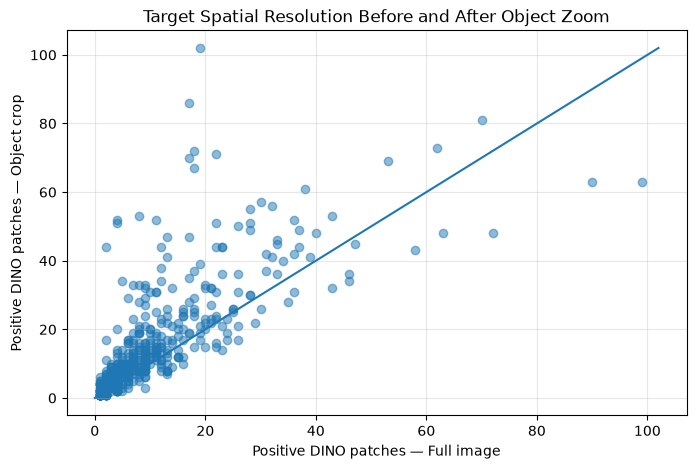

In [27]:
plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    patch_df[
        "full_patches"
    ],
    patch_df[
        "crop_patches"
    ],
    alpha=0.5,
)

maximum = max(
    patch_df[
        "full_patches"
    ].max(),
    patch_df[
        "crop_patches"
    ].max(),
)

plt.plot(
    [0, maximum],
    [0, maximum],
)

plt.xlabel(
    "Positive DINO patches — Full image"
)

plt.ylabel(
    "Positive DINO patches — Object crop"
)

plt.title(
    "Target Spatial Resolution Before and After Object Zoom"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [28]:
PIN_MEMORY = (
    DEVICE.type == "cuda"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

In [29]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(
    DEVICE
)

dino.eval()

for p in dino.parameters():
    p.requires_grad = False

print(
    "DINOv2 loaded and frozen."
)

Using cache found in /home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/utn/ojug99ek/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded and frozen.


In [30]:
clip_model, _, _ = (
    open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai",
    )
)

clip_tokenizer = (
    open_clip.get_tokenizer(
        "ViT-B-32"
    )
)

clip_model = (
    clip_model
    .to(DEVICE)
)

clip_model.eval()

for p in clip_model.parameters():
    p.requires_grad = False

print(
    "CLIP loaded and frozen."
)

/home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded and frozen.


In [31]:
class TextEmbeddingCache:

    def __init__(
        self,
        model,
        tokenizer,
        device,
    ):

        self.model = model
        self.tokenizer = tokenizer
        self.device = device

        self.cache = {}


    @torch.no_grad()
    def _encode_missing(
        self,
        queries,
    ):

        missing = sorted(
            {
                q
                for q in queries
                if q not in self.cache
            }
        )

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = (
            self.tokenizer(
                prompts
            )
            .to(self.device)
        )

        embeddings = (
            self.model.encode_text(
                tokens
            )
        )

        embeddings = F.normalize(
            embeddings.float(),
            dim=-1,
        )

        for query, embedding in zip(
            missing,
            embeddings,
        ):

            self.cache[query] = (
                embedding
                .detach()
                .cpu()
            )


    def __call__(
        self,
        queries,
    ):

        self._encode_missing(
            queries
        )

        result = torch.stack(
            [
                self.cache[q]
                for q in queries
            ]
        )

        return result.to(
            self.device,
            non_blocking=True,
        )

In [32]:
text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

In [33]:
class PartQueryAlignmentSegmenter(nn.Module):

    def __init__(
        self,
        dino_encoder,
        mode,
        visual_dim=128,
        text_common_dim=128,
        text_decoder_dim=32,
        temperature=0.10,
    ):

        super().__init__()

        assert mode in {
            "mask_baseline",
            "alignment_mask",
            "alignment_relative_uv",
        }

        self.mode = mode
        self.temperature = temperature

        self.dino = dino_encoder

        for p in self.dino.parameters():
            p.requires_grad = False


        self.visual_projection = (
            nn.Conv2d(
                384,
                visual_dim,
                kernel_size=1,
            )
        )


        self.text_projection = (
            nn.Sequential(
                nn.Linear(
                    512,
                    text_common_dim,
                ),
                nn.GELU(),
            )
        )


        self.text_decoder_projection = (
            nn.Linear(
                text_common_dim,
                text_decoder_dim,
            )
        )


        fusion_dim = (
            visual_dim
            + text_decoder_dim
            + 1
            + 2
            + 1
        )


        self.decoder = nn.Sequential(

            nn.Conv2d(
                fusion_dim,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                128,
            ),

            nn.GELU(),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                64,
            ),

            nn.GELU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.GELU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=1,
            ),
        )


    def train(
        self,
        mode=True,
    ):

        super().train(mode)

        self.dino.eval()

        return self


    @torch.no_grad()
    def extract_dino_features(
        self,
        images,
    ):

        output = (
            self.dino.forward_features(
                images
            )
        )

        tokens = output[
            "x_norm_patchtokens"
        ]

        b, n, c = tokens.shape

        grid = int(
            n ** 0.5
        )

        return (
            tokens
            .transpose(1, 2)
            .reshape(
                b,
                c,
                grid,
                grid,
            )
        )


    def compute_alignment(
        self,
        visual,
        text_common,
    ):

        visual_normalized = (
            F.normalize(
                visual,
                dim=1,
            )
        )

        text_normalized = (
            F.normalize(
                text_common,
                dim=1,
            )
        )

        text_spatial = (
            text_normalized[
                :,
                :,
                None,
                None,
            ]
        )

        cosine_similarity = (
            visual_normalized
            * text_spatial
        ).sum(
            dim=1,
            keepdim=True,
        )

        alignment_logits = (
            cosine_similarity
            / self.temperature
        )

        alignment_probability = (
            torch.sigmoid(
                alignment_logits
            )
        )

        return (
            alignment_logits,
            alignment_probability,
        )


    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
        relative_u,
        relative_v,
    ):

        dino_features = (
            self.extract_dino_features(
                images
            )
        )


        visual = (
            self.visual_projection(
                dino_features
            )
        )


        text_common = (
            self.text_projection(
                text_embeddings
            )
        )


        text_decoder = (
            self.text_decoder_projection(
                text_common
            )
        )


        text_map = (
            text_decoder[
                :,
                :,
                None,
                None,
            ]
            .expand(
                -1,
                -1,
                visual.shape[-2],
                visual.shape[-1],
            )
        )


        (
            alignment_logits,
            alignment_probability,
        ) = self.compute_alignment(
            visual,
            text_common,
        )


        spatial_size = (
            visual.shape[-2:]
        )


        mask_low = F.interpolate(
            object_mask,
            size=spatial_size,
            mode="nearest",
        )


        alignment_map = (
            alignment_probability
            * mask_low
        )


        u_low = F.interpolate(
            relative_u,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )


        v_low = F.interpolate(
            relative_v,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )


        u_low *= mask_low
        v_low *= mask_low


        if self.mode == "mask_baseline":

            alignment_input = (
                torch.zeros_like(
                    alignment_map
                )
            )

            u_input = (
                torch.zeros_like(
                    u_low
                )
            )

            v_input = (
                torch.zeros_like(
                    v_low
                )
            )


        elif self.mode == "alignment_mask":

            alignment_input = (
                alignment_map
            )

            u_input = (
                torch.zeros_like(
                    u_low
                )
            )

            v_input = (
                torch.zeros_like(
                    v_low
                )
            )


        else:

            alignment_input = (
                alignment_map
            )

            u_input = u_low
            v_input = v_low


        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
                u_input,
                v_input,
                alignment_input,
            ],
            dim=1,
        )


        logits_low = (
            self.decoder(
                fused
            )
        )


        logits = F.interpolate(
            logits_low,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )


        aux = {
            "alignment_logits":
                alignment_logits,

            "alignment_map":
                alignment_map,
        }


        return (
            logits,
            aux,
        )

In [34]:
print(
    PartQueryAlignmentSegmenter.__dict__.keys()
)

dict_keys(['__module__', '__init__', 'train', 'extract_dino_features', 'compute_alignment', 'forward', '__doc__'])


In [35]:
def create_alignment_targets(
    part_mask,
    object_mask,
    output_size,
):

    target_low = (
        F.adaptive_max_pool2d(
            part_mask,
            output_size,
        )
    )

    valid_low = (
        F.adaptive_max_pool2d(
            object_mask,
            output_size,
        )
    )

    target_low *= valid_low

    return (
        target_low,
        valid_low,
    )

In [36]:
def dice_loss(
    logits,
    targets,
    eps=1e-6,
):

    probabilities = (
        torch.sigmoid(logits)
        .flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        probabilities
        * targets
    ).sum(dim=1)

    denominator = (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
    )

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return (
        1 - dice
    ).mean()


def segmentation_loss(
    logits,
    targets,
):

    bce = (
        F.binary_cross_entropy_with_logits(
            logits,
            targets,
        )
    )

    dice = dice_loss(
        logits,
        targets,
    )

    return (
        bce + dice
    )

In [37]:
def alignment_loss(
    alignment_logits,
    part_mask,
    object_mask,
):

    target_low, valid_low = (
        create_alignment_targets(
            part_mask,
            object_mask,
            alignment_logits.shape[-2:],
        )
    )

    loss_map = (
        F.binary_cross_entropy_with_logits(
            alignment_logits,
            target_low,
            reduction="none",
        )
    )

    bce = (
        (
            loss_map
            * valid_low
        ).sum()
        /
        valid_low.sum()
        .clamp_min(1.0)
    )


    probability = (
        torch.sigmoid(
            alignment_logits
        )
        * valid_low
    )

    target = (
        target_low
        * valid_low
    )


    probability = (
        probability.flatten(1)
    )

    target = (
        target.flatten(1)
    )


    intersection = (
        probability
        * target
    ).sum(dim=1)

    denominator = (
        probability.sum(dim=1)
        + target.sum(dim=1)
    )


    dice = (
        1
        -
        (
            2 * intersection
            + 1e-6
        )
        /
        (
            denominator
            + 1e-6
        )
    ).mean()


    return (
        bce + dice
    )

In [38]:
def compute_total_loss(
    mode,
    logits,
    aux,
    part_mask,
    object_mask,
):

    seg = segmentation_loss(
        logits,
        part_mask,
    )

    if mode == "mask_baseline":

        return seg


    align = alignment_loss(
        aux[
            "alignment_logits"
        ],
        part_mask,
        object_mask,
    )


    return (
        seg
        +
        ALIGNMENT_LOSS_WEIGHT
        * align
    )

In [39]:
@torch.no_grad()
def batch_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    prediction = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    prediction = (
        prediction.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        prediction
        & targets
    ).sum(dim=1).float()

    union = (
        prediction
        | targets
    ).sum(dim=1).float()

    return (
        intersection + eps
    ) / (
        union + eps
    )


@torch.no_grad()
def batch_dice(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    prediction = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    prediction = (
        prediction.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        prediction
        & targets
    ).sum(dim=1).float()

    denominator = (
        prediction.sum(dim=1)
        + targets.sum(dim=1)
    ).float()

    return (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

In [40]:
def run_crop_epoch(
    model,
    mode,
    loader,
    optimizer=None,
    scaler=None,
    max_batches=None,
):

    training = (
        optimizer is not None
    )

    if training:
        model.train()
    else:
        model.eval()


    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0

    total_samples = 0


    for batch_index, batch in enumerate(
        loader
    ):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break


        images = (
            batch["crop_image"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        objects = (
            batch["crop_object_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        targets = (
            batch["crop_part_mask"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        u = (
            batch["crop_relative_u"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        v = (
            batch["crop_relative_v"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )


        text = text_encoder(
            batch["query"]
        )


        batch_size = (
            images.shape[0]
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                logits, aux = model(
                    images,
                    text,
                    objects,
                    u,
                    v,
                )


                loss = compute_total_loss(
                    mode,
                    logits,
                    aux,
                    targets,
                    objects,
                )


            if training:

                if scaler is not None:

                    scaler.scale(
                        loss
                    ).backward()

                    scaler.unscale_(
                        optimizer
                    )

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p
                            in model.parameters()
                            if p.requires_grad
                        ),
                        1.0,
                    )

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    loss.backward()

                    optimizer.step()


        with torch.no_grad():

            ious = batch_iou(
                logits,
                targets,
            )

            dices = batch_dice(
                logits,
                targets,
            )


        total_loss += (
            loss.item()
            * batch_size
        )

        total_iou += (
            ious.sum().item()
        )

        total_dice += (
            dices.sum().item()
        )

        total_samples += (
            batch_size
        )


    return {
        "loss":
            total_loss
            / total_samples,

        "iou":
            total_iou
            / total_samples,

        "dice":
            total_dice
            / total_samples,
    }

In [41]:
def get_trainable_state(
    model,
):

    return {
        "visual_projection":
            model.visual_projection
            .state_dict(),

        "text_projection":
            model.text_projection
            .state_dict(),

        "text_decoder_projection":
            model.text_decoder_projection
            .state_dict(),

        "decoder":
            model.decoder
            .state_dict(),
    }


def load_trainable_state(
    model,
    checkpoint,
):

    state = checkpoint[
        "model_state"
    ]

    model.visual_projection.load_state_dict(
        state["visual_projection"]
    )

    model.text_projection.load_state_dict(
        state["text_projection"]
    )

    model.text_decoder_projection.load_state_dict(
        state[
            "text_decoder_projection"
        ]
    )

    model.decoder.load_state_dict(
        state["decoder"]
    )

In [42]:
def train_crop_experiment(
    mode,
    epochs=20,
):

    seed_everything(
        SEED
    )

    experiment_dir = (
        OUTPUT_ROOT
        / mode
    )

    experiment_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    model = (
        PartQueryAlignmentSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_common_dim=TEXT_COMMON_DIM,
            text_decoder_dim=TEXT_DECODER_DIM,
            temperature=ALIGNMENT_TEMPERATURE,
        )
        .to(DEVICE)
    )


    optimizer = (
        torch.optim.AdamW(
            (
                p
                for p
                in model.parameters()
                if p.requires_grad
            ),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )
    )


    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
        )
    )


    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )


    config = {
        "mode": mode,
        "seed": SEED,
        "image_size": IMAGE_SIZE,
        "context_ratio":
            CROP_CONTEXT_RATIO,
        "epochs": epochs,
        "learning_rate":
            LEARNING_RATE,
        "alignment_loss_weight":
            ALIGNMENT_LOSS_WEIGHT,
    }


    with open(
        experiment_dir
        / "config.json",
        "w",
    ) as f:

        json.dump(
            config,
            f,
            indent=2,
        )


    history = []

    best_val_iou = -1.0


    for epoch in range(
        1,
        epochs + 1,
    ):

        start = time.time()


        train_metrics = run_crop_epoch(
            model,
            mode,
            train_loader,
            optimizer=optimizer,
            scaler=scaler,
        )


        with torch.no_grad():

            val_metrics = run_crop_epoch(
                model,
                mode,
                val_loader,
            )


        scheduler.step(
            val_metrics["iou"]
        )


        elapsed = (
            time.time()
            - start
        )


        row = {
            "epoch": epoch,

            "train_loss":
                train_metrics["loss"],

            "train_iou":
                train_metrics["iou"],

            "val_loss":
                val_metrics["loss"],

            "val_iou":
                val_metrics["iou"],

            "val_dice":
                val_metrics["dice"],

            "seconds":
                elapsed,
        }


        history.append(
            row
        )


        print(
            f"[{mode}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train IoU "
            f"{train_metrics['iou']:.4f} | "
            f"val IoU "
            f"{val_metrics['iou']:.4f} | "
            f"val Dice "
            f"{val_metrics['dice']:.4f} | "
            f"{elapsed:.1f}s"
        )


        checkpoint = {
            "epoch": epoch,

            "mode": mode,

            "model_state":
                get_trainable_state(
                    model
                ),

            "val_metrics":
                val_metrics,

            "config":
                config,
        }


        torch.save(
            checkpoint,
            experiment_dir
            / "last.pt",
        )


        if (
            val_metrics["iou"]
            > best_val_iou
        ):

            best_val_iou = (
                val_metrics["iou"]
            )

            torch.save(
                checkpoint,
                experiment_dir
                / "best.pt",
            )

            print(
                "  -> saved new best checkpoint"
            )


        with open(
            experiment_dir
            / "history.json",
            "w",
        ) as f:

            json.dump(
                history,
                f,
                indent=2,
            )


    return (
        model,
        history,
    )

In [43]:
smoke_model = (
    PartQueryAlignmentSegmenter(
        dino_encoder=dino,
        mode="alignment_mask",
        visual_dim=VISUAL_DIM,
        text_common_dim=TEXT_COMMON_DIM,
        text_decoder_dim=TEXT_DECODER_DIM,
        temperature=ALIGNMENT_TEMPERATURE,
    )
    .to(DEVICE)
)


smoke_optimizer = (
    torch.optim.AdamW(
        (
            p
            for p
            in smoke_model.parameters()
            if p.requires_grad
        ),
        lr=LEARNING_RATE,
    )
)


smoke_scaler = (
    torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
)


smoke_result = run_crop_epoch(
    smoke_model,
    "alignment_mask",
    train_loader,
    optimizer=smoke_optimizer,
    scaler=smoke_scaler,
    max_batches=2,
)


print(smoke_result)

{'loss': 1.8213704824447632, 'iou': 0.005468370285164781, 'dice': 0.010271842483710714}


In [44]:
del smoke_model
del smoke_optimizer
del smoke_scaler

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [45]:
crop_mask_model, crop_mask_history = (
    train_crop_experiment(
        "mask_baseline",
        EPOCHS,
    )
)

[mask_baseline] Epoch 01/20 | train IoU 0.1847 | val IoU 0.2405 | val Dice 0.3297 | 141.1s
  -> saved new best checkpoint
[mask_baseline] Epoch 02/20 | train IoU 0.2590 | val IoU 0.2744 | val Dice 0.3663 | 143.8s
  -> saved new best checkpoint
[mask_baseline] Epoch 03/20 | train IoU 0.2937 | val IoU 0.3092 | val Dice 0.4063 | 138.1s
  -> saved new best checkpoint
[mask_baseline] Epoch 04/20 | train IoU 0.3271 | val IoU 0.3262 | val Dice 0.4275 | 140.1s
  -> saved new best checkpoint
[mask_baseline] Epoch 05/20 | train IoU 0.3465 | val IoU 0.3386 | val Dice 0.4433 | 139.8s
  -> saved new best checkpoint
[mask_baseline] Epoch 06/20 | train IoU 0.3600 | val IoU 0.3307 | val Dice 0.4313 | 143.1s
[mask_baseline] Epoch 07/20 | train IoU 0.3694 | val IoU 0.3459 | val Dice 0.4496 | 145.4s
  -> saved new best checkpoint
[mask_baseline] Epoch 08/20 | train IoU 0.3779 | val IoU 0.3452 | val Dice 0.4483 | 145.5s
[mask_baseline] Epoch 09/20 | train IoU 0.3859 | val IoU 0.3510 | val Dice 0.4536 | 14

In [46]:
crop_alignment_model, crop_alignment_history = (
    train_crop_experiment(
        "alignment_mask",
        EPOCHS,
    )
)

[alignment_mask] Epoch 01/20 | train IoU 0.2311 | val IoU 0.2934 | val Dice 0.3928 | 142.9s
  -> saved new best checkpoint
[alignment_mask] Epoch 02/20 | train IoU 0.3183 | val IoU 0.3275 | val Dice 0.4318 | 143.6s
  -> saved new best checkpoint
[alignment_mask] Epoch 03/20 | train IoU 0.3425 | val IoU 0.3405 | val Dice 0.4462 | 143.6s
  -> saved new best checkpoint
[alignment_mask] Epoch 04/20 | train IoU 0.3565 | val IoU 0.3473 | val Dice 0.4514 | 143.2s
  -> saved new best checkpoint
[alignment_mask] Epoch 05/20 | train IoU 0.3676 | val IoU 0.3556 | val Dice 0.4629 | 146.6s
  -> saved new best checkpoint
[alignment_mask] Epoch 06/20 | train IoU 0.3773 | val IoU 0.3485 | val Dice 0.4513 | 143.8s
[alignment_mask] Epoch 07/20 | train IoU 0.3848 | val IoU 0.3572 | val Dice 0.4628 | 146.1s
  -> saved new best checkpoint
[alignment_mask] Epoch 08/20 | train IoU 0.3930 | val IoU 0.3608 | val Dice 0.4657 | 143.7s
  -> saved new best checkpoint
[alignment_mask] Epoch 09/20 | train IoU 0.3995

In [47]:
crop_uv_model, crop_uv_history = (
    train_crop_experiment(
        "alignment_relative_uv",
        EPOCHS,
    )
)

[alignment_relative_uv] Epoch 01/20 | train IoU 0.2339 | val IoU 0.2928 | val Dice 0.3921 | 140.5s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 02/20 | train IoU 0.3196 | val IoU 0.3280 | val Dice 0.4323 | 140.1s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 03/20 | train IoU 0.3444 | val IoU 0.3439 | val Dice 0.4490 | 145.0s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 04/20 | train IoU 0.3591 | val IoU 0.3509 | val Dice 0.4556 | 149.1s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 05/20 | train IoU 0.3699 | val IoU 0.3573 | val Dice 0.4643 | 152.2s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 06/20 | train IoU 0.3796 | val IoU 0.3524 | val Dice 0.4554 | 145.9s
[alignment_relative_uv] Epoch 07/20 | train IoU 0.3868 | val IoU 0.3617 | val Dice 0.4673 | 141.0s
  -> saved new best checkpoint
[alignment_relative_uv] Epoch 08/20 | train IoU 0.3943 | val IoU 0.3637 | val Dice 0.4690 | 140.0s
  -> saved new best ch

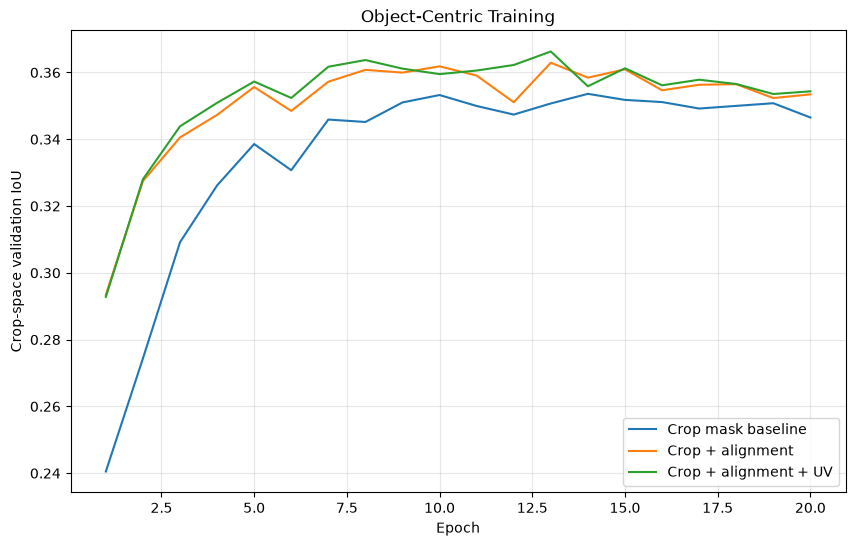

In [48]:
crop_mask_df = pd.DataFrame(
    crop_mask_history
)

crop_alignment_df = pd.DataFrame(
    crop_alignment_history
)

crop_uv_df = pd.DataFrame(
    crop_uv_history
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    crop_mask_df["epoch"],
    crop_mask_df["val_iou"],
    label="Crop mask baseline",
)

plt.plot(
    crop_alignment_df["epoch"],
    crop_alignment_df["val_iou"],
    label="Crop + alignment",
)

plt.plot(
    crop_uv_df["epoch"],
    crop_uv_df["val_iou"],
    label="Crop + alignment + UV",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Crop-space validation IoU"
)

plt.title(
    "Object-Centric Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [49]:
def load_best_crop_model(
    mode,
):

    checkpoint = torch.load(
        OUTPUT_ROOT
        / mode
        / "best.pt",
        map_location=DEVICE,
        weights_only=False,
    )


    model = (
        PartQueryAlignmentSegmenter(
            dino_encoder=dino,
            mode=mode,
            visual_dim=VISUAL_DIM,
            text_common_dim=TEXT_COMMON_DIM,
            text_decoder_dim=TEXT_DECODER_DIM,
            temperature=ALIGNMENT_TEMPERATURE,
        )
        .to(DEVICE)
    )


    load_trainable_state(
        model,
        checkpoint,
    )

    model.eval()

    return model


best_crop_mask = (
    load_best_crop_model(
        "mask_baseline"
    )
)

best_crop_alignment = (
    load_best_crop_model(
        "alignment_mask"
    )
)

best_crop_uv = (
    load_best_crop_model(
        "alignment_relative_uv"
    )
)

## Fair Full-Image Evaluation

Training occurs in crop coordinates.

However, computing IoU directly inside the crop would not be directly
comparable with the full-image models from Notebook 06.

Therefore each crop prediction is:

224 × 224 crop prediction
        ↓
resize back to original crop size
        ↓
place into the original image coordinate system
        ↓
apply the same full-image resize + padding
        ↓
224 × 224 full-image prediction

IoU is then measured against the same full-image ground-truth mask used by
the previous experiments.

In [50]:
def project_crop_probability_to_full(
    crop_probability,
    original_height,
    original_width,
    crop_x1,
    crop_y1,
    crop_side,
    target_size=224,
):

    if crop_probability.ndim == 2:
        crop_probability = (
            crop_probability[
                None,
                None,
            ]
        )

    elif crop_probability.ndim == 3:
        crop_probability = (
            crop_probability[
                None
            ]
        )


    # Convert 224×224 crop prediction
    # back to raw crop dimensions.

    raw_crop_probability = (
        F.interpolate(
            crop_probability,
            size=(
                crop_side,
                crop_side,
            ),
            mode="bilinear",
            align_corners=False,
        )
    )


    raw_canvas = torch.zeros(
        (
            1,
            1,
            original_height,
            original_width,
        ),
        dtype=raw_crop_probability.dtype,
        device=raw_crop_probability.device,
    )


    crop_x2 = (
        crop_x1
        + crop_side
    )

    crop_y2 = (
        crop_y1
        + crop_side
    )


    source_x1 = max(
        0,
        crop_x1,
    )

    source_y1 = max(
        0,
        crop_y1,
    )

    source_x2 = min(
        original_width,
        crop_x2,
    )

    source_y2 = min(
        original_height,
        crop_y2,
    )


    crop_local_x1 = (
        source_x1
        - crop_x1
    )

    crop_local_y1 = (
        source_y1
        - crop_y1
    )

    crop_local_x2 = (
        crop_local_x1
        + source_x2
        - source_x1
    )

    crop_local_y2 = (
        crop_local_y1
        + source_y2
        - source_y1
    )


    raw_canvas[
        :,
        :,
        source_y1:source_y2,
        source_x1:source_x2,
    ] = raw_crop_probability[
        :,
        :,
        crop_local_y1:crop_local_y2,
        crop_local_x1:crop_local_x2,
    ]


    # Now transform raw canvas exactly
    # like the full image.

    info = get_resize_info(
        original_height,
        original_width,
        target_size,
    )


    resized = F.interpolate(
        raw_canvas,
        size=(
            info["new_h"],
            info["new_w"],
        ),
        mode="bilinear",
        align_corners=False,
    )


    full_probability = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )


    return (
        full_probability[0]
    )

In [51]:
@torch.no_grad()
def batch_iou_from_probability(
    probabilities,
    targets,
    threshold=0.5,
    eps=1e-6,
):

    predictions = (
        probabilities
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = (
        predictions.flatten(1)
    )

    targets = (
        targets.flatten(1)
    )

    intersection = (
        predictions
        & targets
    ).sum(dim=1).float()

    union = (
        predictions
        | targets
    ).sum(dim=1).float()

    return (
        intersection + eps
    ) / (
        union + eps
    )

In [52]:
@torch.no_grad()
def evaluate_crop_model_full_space(
    model,
    loader,
):

    model.eval()

    total_iou = 0.0
    total_samples = 0


    for batch in loader:

        images = (
            batch["crop_image"]
            .to(DEVICE)
        )

        objects = (
            batch["crop_object_mask"]
            .to(DEVICE)
        )

        u = (
            batch["crop_relative_u"]
            .to(DEVICE)
        )

        v = (
            batch["crop_relative_v"]
            .to(DEVICE)
        )

        text = text_encoder(
            batch["query"]
        )


        logits, _ = model(
            images,
            text,
            objects,
            u,
            v,
        )


        crop_probability = (
            torch.sigmoid(
                logits
            )
        )


        full_predictions = []


        for i in range(
            images.shape[0]
        ):

            mapped = (
                project_crop_probability_to_full(

                    crop_probability[i],

                    int(
                        batch[
                            "original_height"
                        ][i]
                    ),

                    int(
                        batch[
                            "original_width"
                        ][i]
                    ),

                    int(
                        batch[
                            "crop_x1"
                        ][i]
                    ),

                    int(
                        batch[
                            "crop_y1"
                        ][i]
                    ),

                    int(
                        batch[
                            "crop_side"
                        ][i]
                    ),
                )
            )

            full_predictions.append(
                mapped
            )


        full_predictions = torch.stack(
            full_predictions
        )


        targets = (
            batch[
                "full_part_mask"
            ]
            .to(DEVICE)
        )


        ious = (
            batch_iou_from_probability(
                full_predictions,
                targets,
            )
        )


        total_iou += (
            ious.sum().item()
        )

        total_samples += (
            images.shape[0]
        )


    return {
        "iou":
            total_iou
            / total_samples
    }

In [53]:
crop_mask_seen = (
    evaluate_crop_model_full_space(
        best_crop_mask,
        test_seen_loader,
    )
)

crop_alignment_seen = (
    evaluate_crop_model_full_space(
        best_crop_alignment,
        test_seen_loader,
    )
)

crop_uv_seen = (
    evaluate_crop_model_full_space(
        best_crop_uv,
        test_seen_loader,
    )
)

print(
    crop_mask_seen
)

print(
    crop_alignment_seen
)

print(
    crop_uv_seen
)

{'iou': 0.36730762409972917}
{'iou': 0.3757177048498995}
{'iou': 0.3771619444535628}


In [54]:
crop_mask_unseen = (
    evaluate_crop_model_full_space(
        best_crop_mask,
        test_unseen_loader,
    )
)

crop_alignment_unseen = (
    evaluate_crop_model_full_space(
        best_crop_alignment,
        test_unseen_loader,
    )
)

crop_uv_unseen = (
    evaluate_crop_model_full_space(
        best_crop_uv,
        test_unseen_loader,
    )
)

print(
    crop_mask_unseen
)

print(
    crop_alignment_unseen
)

print(
    crop_uv_unseen
)

{'iou': 0.2767655636368303}
{'iou': 0.32991450852133136}
{'iou': 0.32120839975219956}


In [55]:
crop_results = pd.DataFrame(
    [
        {
            "model":
                "Crop Mask Baseline",

            "seen_iou":
                crop_mask_seen["iou"],

            "unseen_iou":
                crop_mask_unseen["iou"],
        },

        {
            "model":
                "Crop + Alignment",

            "seen_iou":
                crop_alignment_seen["iou"],

            "unseen_iou":
                crop_alignment_unseen["iou"],
        },

        {
            "model":
                "Crop + Alignment + UV",

            "seen_iou":
                crop_uv_seen["iou"],

            "unseen_iou":
                crop_uv_unseen["iou"],
        },
    ]
)

crop_results

,model,seen_iou,unseen_iou
0,Crop Mask Baseline,0.367308,0.276766
1,Crop + Alignment,0.375718,0.329915
2,Crop + Alignment + UV,0.377162,0.321208


In [56]:
full_results_path = (
    FULL_MODEL_ROOT
    / "alignment_results.csv"
)

if full_results_path.exists():

    full_results = pd.read_csv(
        full_results_path
    )

    display(
        full_results
    )

else:

    print(
        "Notebook 06 result file not found:",
        full_results_path
    )

,model,seen_iou,seen_dice,unseen_iou,unseen_dice,unseen_alignment_iou
0,Mask baseline,0.310237,0.409657,0.196982,0.273686,0.151813
1,Part-query alignment,0.318711,0.420098,0.268927,0.365683,0.496710
2,Alignment + Relative UV,0.320544,0.419953,0.265908,0.359352,0.499427


In [57]:
if full_results_path.exists():

    comparison_rows = []


    mapping = {
        "Mask baseline":
            (
                crop_mask_seen["iou"],
                crop_mask_unseen["iou"],
            ),

        "Part-query alignment":
            (
                crop_alignment_seen["iou"],
                crop_alignment_unseen["iou"],
            ),

        "Alignment + Relative UV":
            (
                crop_uv_seen["iou"],
                crop_uv_unseen["iou"],
            ),
    }


    for _, row in (
        full_results.iterrows()
    ):

        model_name = (
            row["model"]
        )

        if model_name not in mapping:
            continue


        crop_seen, crop_unseen = (
            mapping[
                model_name
            ]
        )


        comparison_rows.append(
            {
                "model":
                    model_name,

                "full_seen_iou":
                    row["seen_iou"],

                "crop_seen_iou":
                    crop_seen,

                "seen_gain":
                    crop_seen
                    - row["seen_iou"],

                "full_unseen_iou":
                    row["unseen_iou"],

                "crop_unseen_iou":
                    crop_unseen,

                "unseen_gain":
                    crop_unseen
                    - row["unseen_iou"],
            }
        )


    zoom_comparison = (
        pd.DataFrame(
            comparison_rows
        )
    )


    display(
        zoom_comparison
    )

,model,full_seen_iou,crop_seen_iou,seen_gain,full_unseen_iou,crop_unseen_iou,unseen_gain
0,Mask baseline,0.310237,0.367308,0.057071,0.196982,0.276766,0.079784
1,Part-query alignment,0.318711,0.375718,0.057006,0.268927,0.329915,0.060988
2,Alignment + Relative UV,0.320544,0.377162,0.056618,0.265908,0.321208,0.055300


# How to Interpret Object-Centric Zoom

## Case 1

Crop > Full Image

especially on unseen objects.

Interpretation:

The coarse spatial resolution of the full-image DINO representation was a
meaningful bottleneck.

Allocating more DINO patches to the parent object improves fine-grained
part representation.

---

## Case 2

Crop improves Alignment more than Mask Baseline

Interpretation:

Higher-resolution object features make DINO–CLIP patch-query alignment more
effective.

---

## Case 3

Crop improves small parts but not large parts

Interpretation:

This strongly supports the intended motivation of object-centric zoom:
increasing effective spatial resolution for fine structures.

---

## Case 4

Crop ≈ Full Image

Interpretation:

Spatial resolution may not be the primary bottleneck.

The model may instead be limited by semantic correspondence, decoder
capacity, or annotation ambiguity.

---

## Case 5

Crop < Full Image

Interpretation:

Global scene context may contain useful information that is lost by
object-centric cropping.

This would motivate a future dual-view architecture rather than crop-only
processing.

In [58]:
def load_full_alignment_model():

    checkpoint_path = (
        FULL_MODEL_ROOT
        / "alignment_mask"
        / "best.pt"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = (
        PartQueryAlignmentSegmenter(
            dino_encoder=dino,
            mode="alignment_mask",
            visual_dim=VISUAL_DIM,
            text_common_dim=TEXT_COMMON_DIM,
            text_decoder_dim=TEXT_DECODER_DIM,
            temperature=ALIGNMENT_TEMPERATURE,
        )
        .to(DEVICE)
    )

    load_trainable_state(
        model,
        checkpoint,
    )

    model.eval()

    return model


best_full_alignment = (
    load_full_alignment_model()
)

In [59]:
@torch.no_grad()
def compare_full_and_crop_alignment(
    loader,
):

    rows = []


    for batch in loader:

        batch_size = (
            batch[
                "full_image"
            ].shape[0]
        )


        text = text_encoder(
            batch["query"]
        )


        # ============================
        # Full image model
        # ============================

        full_images = (
            batch["full_image"]
            .to(DEVICE)
        )

        full_objects = (
            batch["full_object_mask"]
            .to(DEVICE)
        )

        full_u = (
            batch["full_relative_u"]
            .to(DEVICE)
        )

        full_v = (
            batch["full_relative_v"]
            .to(DEVICE)
        )


        full_logits, _ = (
            best_full_alignment(
                full_images,
                text,
                full_objects,
                full_u,
                full_v,
            )
        )


        full_probabilities = (
            torch.sigmoid(
                full_logits
            )
        )


        # ============================
        # Crop model
        # ============================

        crop_images = (
            batch["crop_image"]
            .to(DEVICE)
        )

        crop_objects = (
            batch["crop_object_mask"]
            .to(DEVICE)
        )

        crop_u = (
            batch["crop_relative_u"]
            .to(DEVICE)
        )

        crop_v = (
            batch["crop_relative_v"]
            .to(DEVICE)
        )


        crop_logits, _ = (
            best_crop_alignment(
                crop_images,
                text,
                crop_objects,
                crop_u,
                crop_v,
            )
        )


        crop_probabilities = (
            torch.sigmoid(
                crop_logits
            )
        )


        mapped_crop = []


        for i in range(
            batch_size
        ):

            mapped = (
                project_crop_probability_to_full(

                    crop_probabilities[i],

                    int(
                        batch[
                            "original_height"
                        ][i]
                    ),

                    int(
                        batch[
                            "original_width"
                        ][i]
                    ),

                    int(
                        batch[
                            "crop_x1"
                        ][i]
                    ),

                    int(
                        batch[
                            "crop_y1"
                        ][i]
                    ),

                    int(
                        batch[
                            "crop_side"
                        ][i]
                    ),
                )
            )

            mapped_crop.append(
                mapped
            )


        mapped_crop = torch.stack(
            mapped_crop
        )


        targets = (
            batch["full_part_mask"]
            .to(DEVICE)
        )


        full_ious = (
            batch_iou_from_probability(
                full_probabilities,
                targets,
            )
        )


        crop_ious = (
            batch_iou_from_probability(
                mapped_crop,
                targets,
            )
        )


        for i in range(
            batch_size
        ):

            rows.append(
                {
                    "sample_id":
                        batch[
                            "sample_id"
                        ][i],

                    "object":
                        batch[
                            "object_name"
                        ][i],

                    "part":
                        batch[
                            "part_name"
                        ][i],

                    "part_ratio":
                        float(
                            batch[
                                "part_to_object_ratio"
                            ][i]
                        ),

                    "full_iou":
                        float(
                            full_ious[i]
                        ),

                    "crop_iou":
                        float(
                            crop_ious[i]
                        ),

                    "gain":
                        float(
                            crop_ious[i]
                            - full_ious[i]
                        ),
                }
            )


    return pd.DataFrame(
        rows
    )

In [60]:
size_analysis = (
    compare_full_and_crop_alignment(
        test_unseen_loader
    )
)

size_analysis.head()

,sample_id,object,part,part_ratio,full_iou,crop_iou,gain
0,val:2008_000080:part_60,dog,tail,0.007448,0.282609,4.000000e-01,0.117391
1,val:2008_000080:part_61,dog,head,0.112289,0.611111,6.360424e-01,0.024931
2,val:2008_000080:part_62,dog,eye,0.003437,0.082192,1.851852e-08,-0.082192
3,val:2008_000080:part_63,dog,torso,0.523059,0.728728,8.283621e-01,0.099634
4,val:2008_000080:part_65,dog,leg,0.217703,0.333581,5.183246e-01,0.184744


In [61]:
q1 = size_analysis[
    "part_ratio"
].quantile(
    1 / 3
)

q2 = size_analysis[
    "part_ratio"
].quantile(
    2 / 3
)

print(
    "33rd percentile:",
    q1
)

print(
    "66th percentile:",
    q2
)

33rd percentile: 0.024325509866078683
66th percentile: 0.12624234954516092


In [62]:
def size_group(
    ratio,
):

    if ratio <= q1:
        return "small"

    if ratio <= q2:
        return "medium"

    return "large"


size_analysis[
    "size_group"
] = (
    size_analysis[
        "part_ratio"
    ].apply(
        size_group
    )
)

In [63]:
size_summary = (
    size_analysis
    .groupby(
        "size_group"
    )
    .agg(
        samples=(
            "sample_id",
            "count",
        ),

        full_iou=(
            "full_iou",
            "mean",
        ),

        crop_iou=(
            "crop_iou",
            "mean",
        ),

        mean_gain=(
            "gain",
            "mean",
        ),
    )
    .reindex(
        [
            "small",
            "medium",
            "large",
        ]
    )
)

size_summary

,samples,full_iou,crop_iou,mean_gain
size_group,,,,
small,529,0.103770,0.135412,0.031642
medium,528,0.284012,0.365107,0.081096
large,529,0.419033,0.489291,0.070258


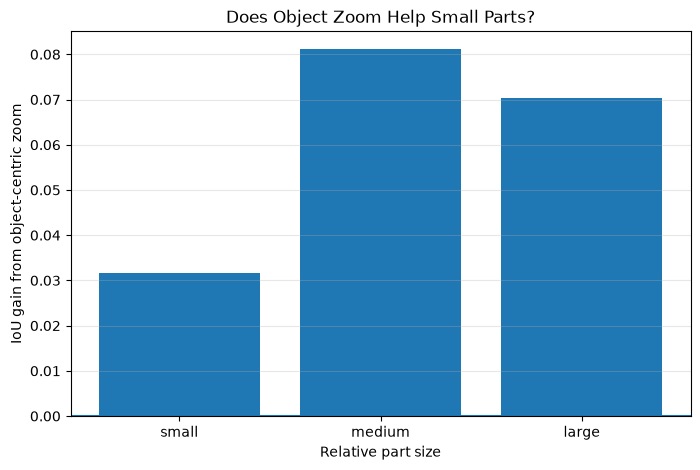

In [64]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    size_summary.index,
    size_summary[
        "mean_gain"
    ],
)

plt.axhline(
    0,
)

plt.xlabel(
    "Relative part size"
)

plt.ylabel(
    "IoU gain from object-centric zoom"
)

plt.title(
    "Does Object Zoom Help Small Parts?"
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.show()

In [65]:
best_zoom_examples = (
    size_analysis
    .sort_values(
        "gain",
        ascending=False,
    )
    .head(10)
)

best_zoom_examples[
    [
        "sample_id",
        "object",
        "part",
        "part_ratio",
        "full_iou",
        "crop_iou",
        "gain",
    ]
]

,sample_id,object,part,part_ratio,full_iou,crop_iou,gain
512,val:2009_000989:part_66,dog,nose,0.010230,6.249999e-08,0.800000,0.800000
425,val:2009_000156:part_63,dog,torso,0.624609,3.338900e-03,0.785489,0.782150
185,val:2008_003141:part_41,car,window,0.167054,7.651109e-10,0.768041,0.768041
1161,val:2010_001563:part_63,dog,torso,0.467290,9.756102e-03,0.777293,0.767536
1464,val:2010_005013:part_32,car,wheel,0.064121,1.123596e-08,0.760870,0.760870
298,val:2008_006526:part_36,car,back,0.728814,5.813953e-09,0.728972,0.728972
1301,val:2010_003231:part_37,car,roof,0.080967,2.915452e-09,0.718182,0.718182
1021,val:2010_000502:part_13,bird,head,0.049505,2.439024e-08,0.714286,0.714286
231,val:2008_004339:part_32,car,wheel,0.160448,7.751938e-09,0.692810,0.692810
821,val:2009_004070:part_101,sheep,eye,0.009677,2.500000e-08,0.666667,0.666667


In [66]:
worst_zoom_examples = (
    size_analysis
    .sort_values(
        "gain",
        ascending=True,
    )
    .head(10)
)

worst_zoom_examples[
    [
        "sample_id",
        "object",
        "part",
        "part_ratio",
        "full_iou",
        "crop_iou",
        "gain",
    ]
]

,sample_id,object,part,part_ratio,full_iou,crop_iou,gain
1477,val:2010_005159:part_68,dog,ear,0.099290,0.679127,1.871298e-01,-0.491997
148,val:2008_002859:part_66,dog,nose,0.004707,0.473118,5.952381e-09,-0.473118
1034,val:2010_000530:part_41,car,window,0.166780,0.466089,1.721170e-09,-0.466089
1209,val:2010_001995:part_15,bird,beak,0.029682,0.465267,2.409638e-09,-0.465267
207,val:2008_003576:part_63,dog,torso,0.492594,0.668739,2.137528e-01,-0.454986
1265,val:2010_002988:part_41,car,window,0.164840,0.562173,1.096606e-01,-0.452512
225,val:2008_003846:part_41,car,window,0.144823,0.524059,9.598330e-02,-0.428076
1062,val:2010_000814:part_14,bird,eye,0.002030,0.457143,3.125001e-02,-0.425893
227,val:2008_004069:part_33,car,headlight,0.035071,0.607080,1.883117e-01,-0.418768
1528,val:2010_005501:part_41,car,window,0.228519,0.595445,1.813422e-01,-0.414103


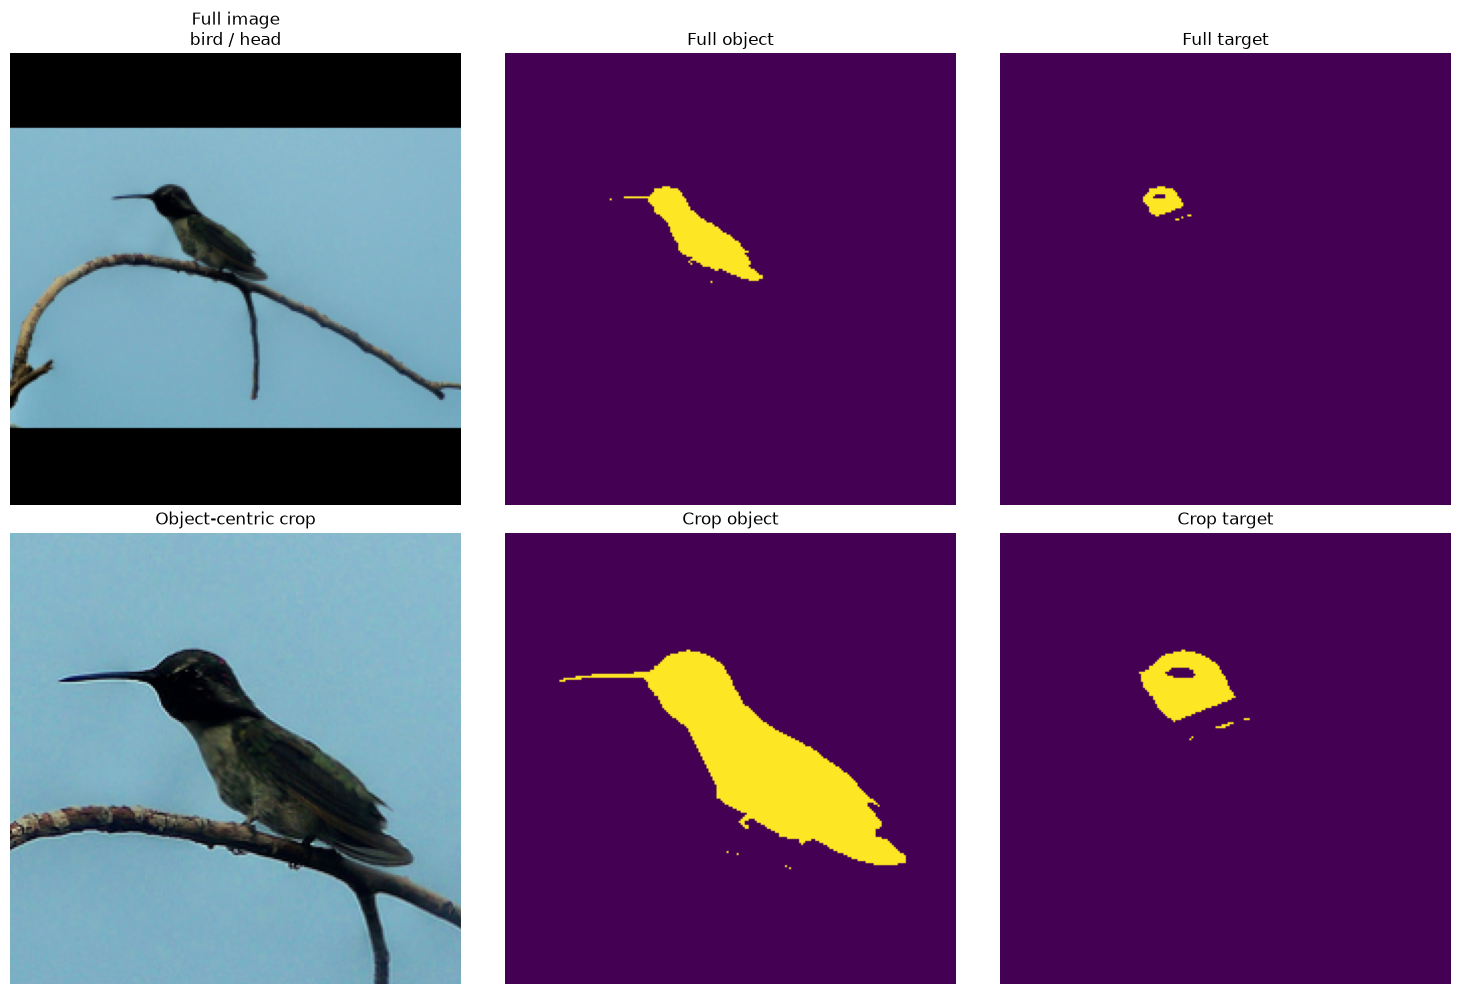

In [67]:
QUALITATIVE_INDEX = 10

sample = (
    test_unseen_dataset[
        QUALITATIVE_INDEX
    ]
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
)


axes[0, 0].imshow(
    sample[
        "full_display_image"
    ]
    .permute(1, 2, 0)
)

axes[0, 0].set_title(
    f"Full image\n"
    f"{sample['object_name']} / "
    f"{sample['part_name']}"
)


axes[0, 1].imshow(
    sample[
        "full_object_mask"
    ].squeeze()
)

axes[0, 1].set_title(
    "Full object"
)


axes[0, 2].imshow(
    sample[
        "full_part_mask"
    ].squeeze()
)

axes[0, 2].set_title(
    "Full target"
)


axes[1, 0].imshow(
    sample[
        "crop_display_image"
    ]
    .permute(1, 2, 0)
)

axes[1, 0].set_title(
    "Object-centric crop"
)


axes[1, 1].imshow(
    sample[
        "crop_object_mask"
    ].squeeze()
)

axes[1, 1].set_title(
    "Crop object"
)


axes[1, 2].imshow(
    sample[
        "crop_part_mask"
    ].squeeze()
)

axes[1, 2].set_title(
    "Crop target"
)


for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [68]:
crop_results.to_csv(
    OUTPUT_ROOT
    / "crop_results.csv",
    index=False,
)

patch_df.to_csv(
    OUTPUT_ROOT
    / "patch_resolution_analysis.csv",
    index=False,
)

size_analysis.to_csv(
    OUTPUT_ROOT
    / "part_size_analysis.csv",
    index=False,
)

size_summary.to_csv(
    OUTPUT_ROOT
    / "part_size_summary.csv",
)

if (
    "zoom_comparison"
    in globals()
):

    zoom_comparison.to_csv(
        OUTPUT_ROOT
        / "full_vs_crop_results.csv",
        index=False,
    )

print(
    "Results saved under:",
    OUTPUT_ROOT
)

Results saved under: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/object_centric_zoom


# Notebook 07 Summary

This notebook investigated whether the coarse spatial resolution of the
full-image DINO representation limits fine-grained part segmentation.

---

## Object-Centric Zoom

The parent-object mask was used to calculate a square object crop with
15% surrounding context.

Importantly, the crop was extracted from the original-resolution image
before resizing.

The crop was then resized directly to 224 × 224.

Therefore the selected object occupies substantially more of DINOv2's
16 × 16 patch grid.

---

## Spatial Resolution Analysis

For every target part we measured how many DINO patches contained at least
one target pixel.

We compared:

full-image target patch coverage

against

object-crop target patch coverage.

This directly measures the effective increase in spatial resolution.

---

## Models

Three crop-based models were trained:

1. Mask baseline
2. Part-query alignment
3. Part-query alignment + Relative U/V

The architecture matches Notebook 06.

---

## Fair Evaluation

Crop predictions were projected back into the original/full-image coordinate
system before final IoU calculation.

This allows direct comparison with the full-image models from Notebook 06.

---

## Fine-Grained Analysis

Performance was additionally analyzed according to relative part size.

This helps determine whether object-centric zoom particularly benefits
small parts, which is its primary motivation.

---

## Main Questions

Object crop vs full image:

Does allocating more DINO patches to the parent object improve segmentation?

Small vs large parts:

Are improvements concentrated on fine structures?

Alignment + crop:

Does increased spatial resolution improve visual-language grounding?

UV after crop:

Does explicit object-relative geometry remain useful once the object itself
is represented at higher resolution?